# Info

## Fields

### Target
price - Price of the Houses

### Features
area - Area of a House

bedrooms - Number of House Bedrooms

bathrooms - Number if Bathrooms

stories - Number of House Stories

mainroad - Weather connected to Main Road

guestroom - Weather has a guest room

basement - Weather has a basement

hotwaterheating - Weather has a hotwater heater

airconditioning - Weather has an airconditioning

parking - Number of House Parkings

prefarea - Prefarea of the House

furnishingstatus - Furnishing status of the House

# Import

In [88]:
import pandas as pd
import sklearn as sk
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns


## Data preparing

In [14]:
data = pd.read_csv(r'datas/Housing.csv')
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [15]:
mp = {'no': 0, 'yes': 1, 'furnished': 1, 'semi-furnished': 0.5, 'unfurnished': 0}
clas = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
for i in clas:
    data[i] = data[i].map(mp)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1.0,0.0,0.0,0.0,1.0,2,1.0,1.0
1,12250000,8960,4,4,4,1.0,0.0,0.0,0.0,1.0,3,0.0,1.0
2,12250000,9960,3,2,2,1.0,0.0,1.0,0.0,0.0,2,1.0,0.5
3,12215000,7500,4,2,2,1.0,0.0,1.0,0.0,1.0,3,1.0,1.0
4,11410000,7420,4,1,2,1.0,1.0,1.0,0.0,1.0,2,0.0,1.0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              545 non-null    int64  
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    float64
 6   guestroom         545 non-null    float64
 7   basement          545 non-null    float64
 8   hotwaterheating   545 non-null    float64
 9   airconditioning   545 non-null    float64
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    float64
 12  furnishingstatus  545 non-null    float64
dtypes: float64(7), int64(6)
memory usage: 55.5 KB


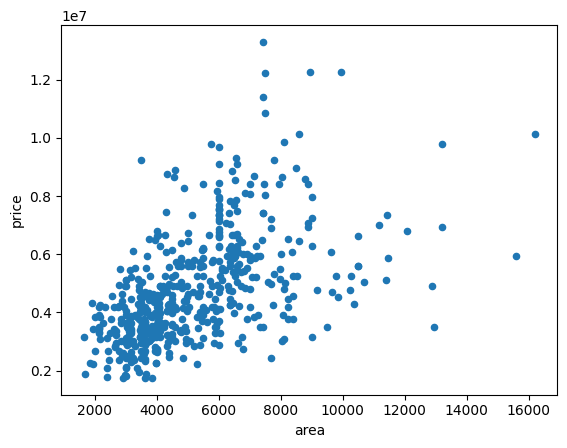

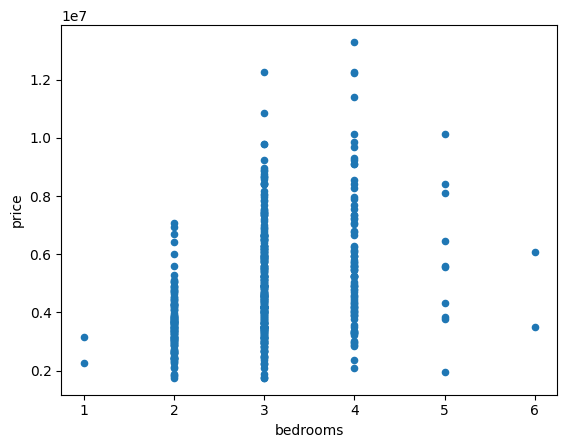

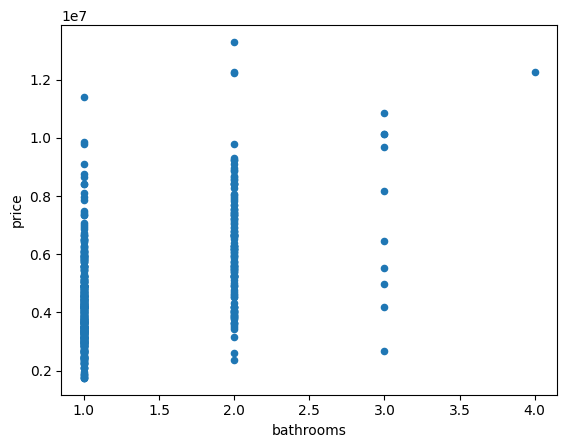

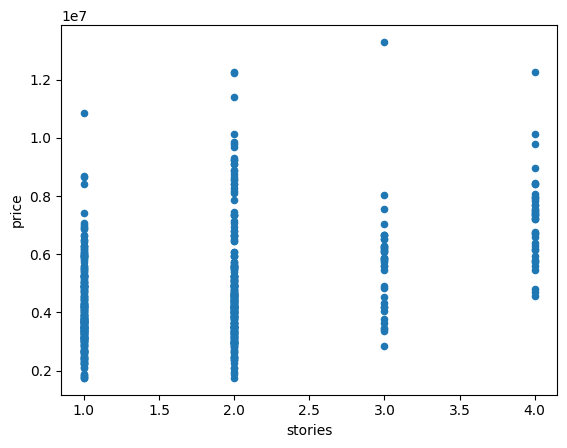

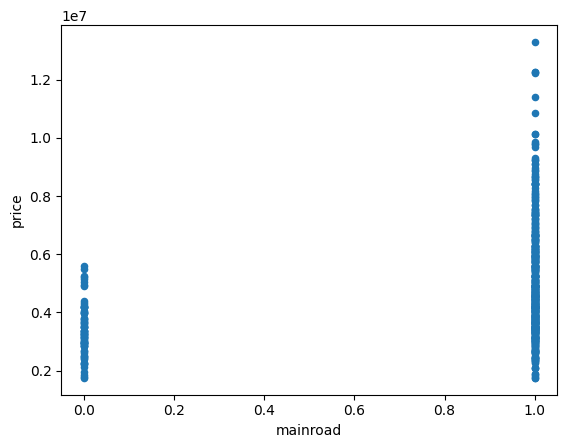

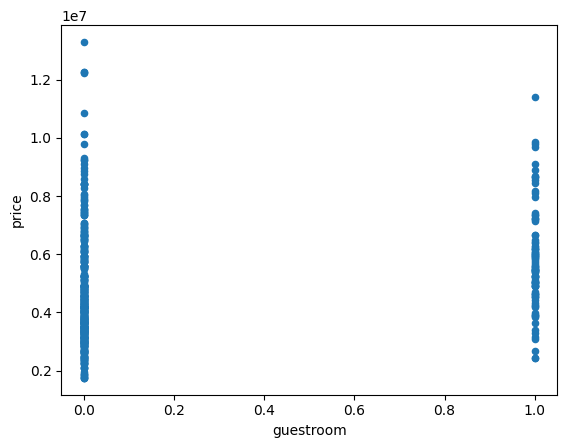

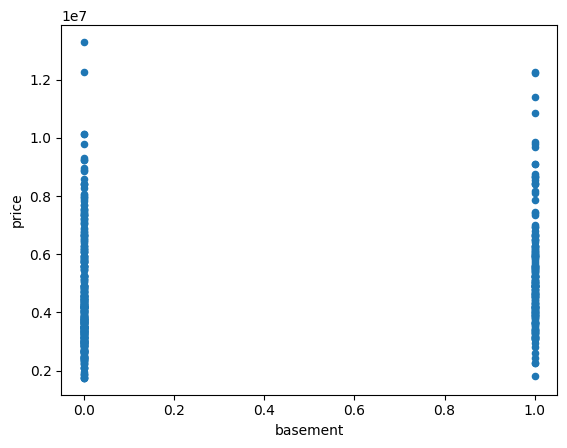

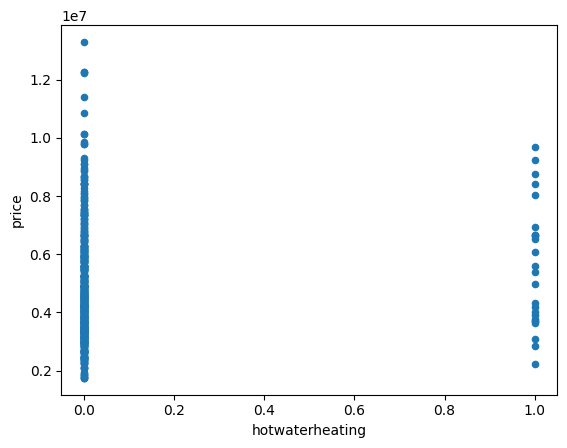

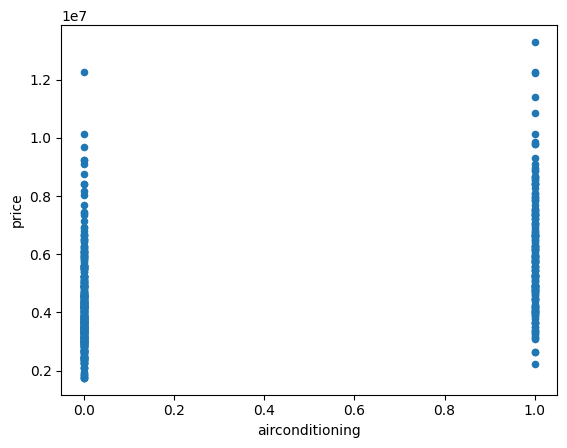

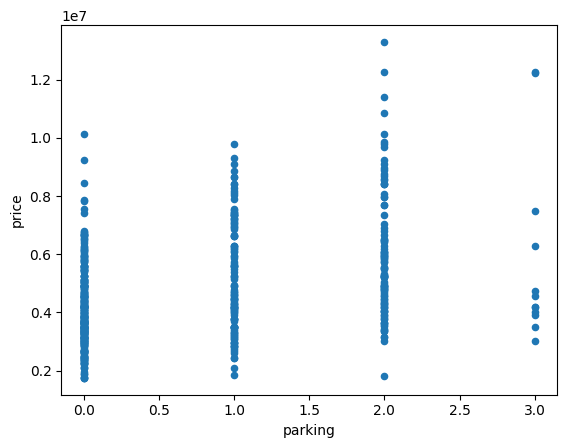

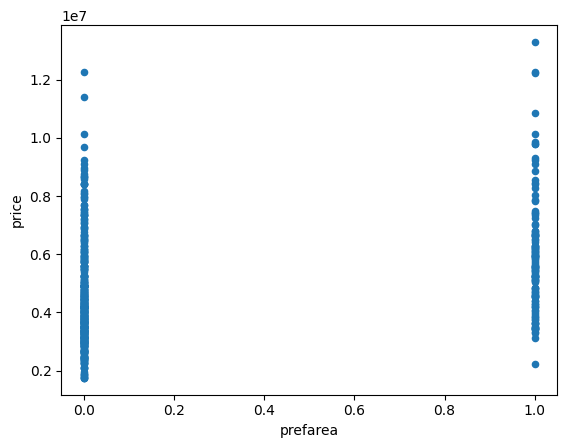

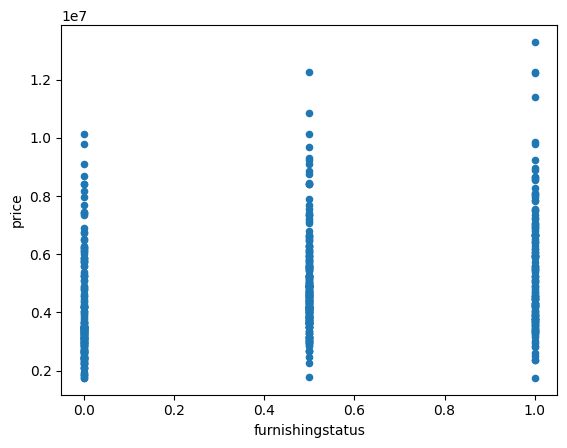

In [87]:
for c in data.columns[1:]:
    data.plot.scatter(c, 'price')
    plt.show()

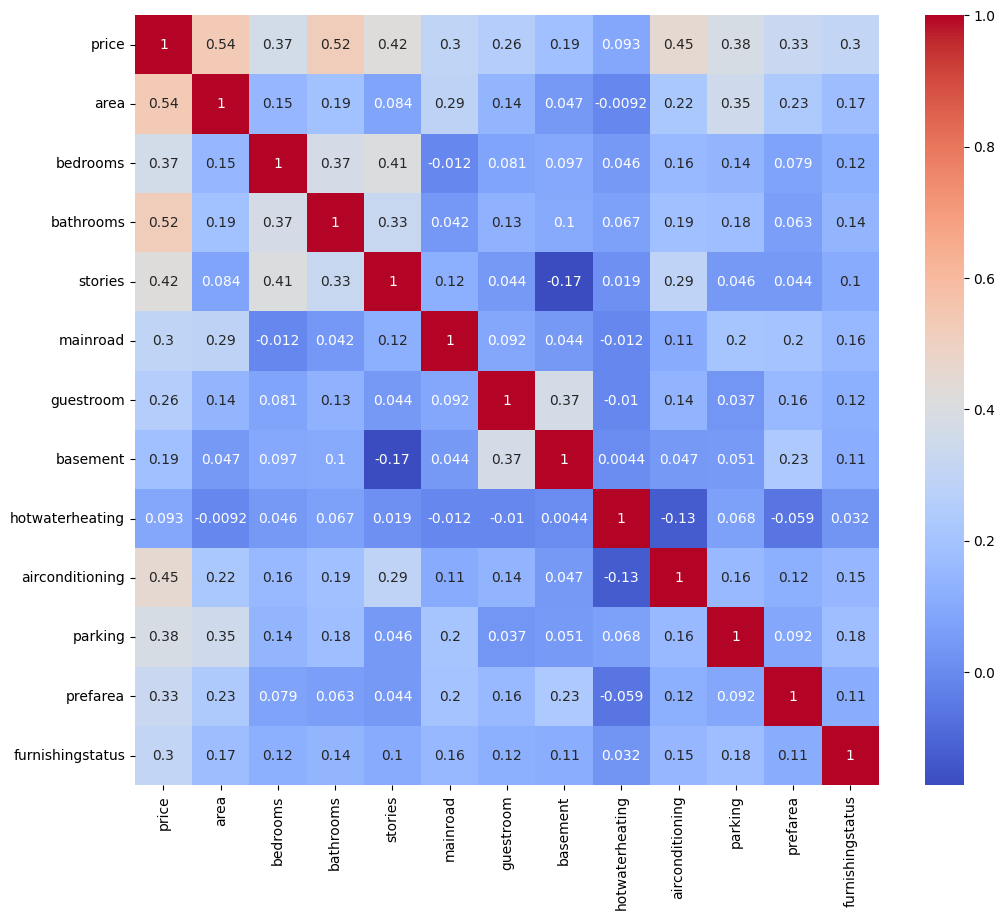

In [32]:
cor = data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cor, annot=True, cmap='coolwarm')
plt.show()

# Models + log in Mlflow

In [94]:
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('Python_final_exam_1_year_2_sem')

<Experiment: artifact_location='/mlflow/artifacts/1', creation_time=1777046433637, experiment_id='1', last_update_time=1777046433637, lifecycle_stage='active', name='Python_final_exam_1_year_2_sem', tags={}, workspace='default'>

In [35]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(data.drop('price', axis=1), data['price'], test_size=0.2, random_state=42)

In [47]:
model_lin = sk.linear_model.LinearRegression()
model_lin.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:
y_pred = model_lin.predict(X_test)

In [98]:
print('Mae:', sk.metrics.mean_absolute_error(y_test, y_pred))
print('Mse:', sk.metrics.mean_squared_error(y_test, y_pred))
print('R2:', sk.metrics.r2_score(y_test, y_pred)) 
print('dispersion:', sk.metrics.explained_variance_score(y_test, y_pred))

Mae: 979679.6912959906
Mse: 1771751116594.036
R2: 0.6494754192267802
dispersion: 0.6533855956667481


In [103]:
def logg(name, y_pred):
    with mlflow.start_run(run_name=name):
        mae = sk.metrics.mean_absolute_error(y_test, y_pred)
        mse = sk.metrics.mean_squared_error(y_test, y_pred)
        r2 = sk.metrics.r2_score(y_test, y_pred)
        disper = sk.metrics.explained_variance_score(y_test, y_pred)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("r2", r2)
        mlflow.log_metric("dispersion", disper)
    print(f'Mae {mae}, Mse {mse}, R2 {r2}, dispersion {disper}')

In [104]:
logg('Linear Regression', y_pred)

🏃 View run Linear Regression at: http://localhost:5000/#/experiments/1/runs/74b6c446e8a24979b74a612967769303
🧪 View experiment at: http://localhost:5000/#/experiments/1
Mae 979679.6912959906, Mse 1771751116594.036, R2 0.6494754192267802, dispersion 0.6533855956667481
